In [ ]:
# Step 1: Install required libraries
#!pip install datasets

# Step 2: Import libraries
import re
import torch
import torch.nn as nn
import torch.optim as optim
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from collections import Counter
import random
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('gdrive')

Mounted at gdrive


In [ ]:
!unzip /content/gdrive/MyDrive/ijcnlp_dailydialog.zip

Archive:  /content/gdrive/MyDrive/ijcnlp_dailydialog.zip
   creating: ijcnlp_dailydialog/
  inflating: ijcnlp_dailydialog/.DS_Store  
  inflating: ijcnlp_dailydialog/dialogues_act.txt  
  inflating: ijcnlp_dailydialog/dialogues_emotion.txt  
  inflating: ijcnlp_dailydialog/dialogues_text.txt  
  inflating: ijcnlp_dailydialog/dialogues_topic.txt  
  inflating: ijcnlp_dailydialog/readme.txt  
  inflating: ijcnlp_dailydialog/test.zip  
 extracting: ijcnlp_dailydialog/train.zip  
  inflating: ijcnlp_dailydialog/validation.zip  


In [ ]:
import re

# Preprocessing - lowercasing and removing punctuation
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text

questions = []
answers = []

# Read and process the entire dialogues_text.txt file
with open('/content/ijcnlp_dailydialog/dialogues_text.txt', 'r', encoding='utf-8') as f:
    for line in f:
        utterances = line.strip().split("__eou__")
        utterances = [preprocess(u.strip()) for u in utterances if u.strip()]
        for i in range(len(utterances) - 1):
            questions.append(utterances[i])
            answers.append(utterances[i + 1])

# Show a sample
print("Total Q&A pairs extracted:", len(questions))
print("Sample question:", questions[0])
print("Sample answer:", answers[0])

Total Q&A pairs extracted: 89862
Sample question: the kitchen stinks 
Sample answer: ill throw out the garbage 


In [ ]:
# Special tokens
PAD_TOKEN = "<pad>"
BOS_TOKEN = "<bos>"
EOS_TOKEN = "<eos>"
UNK_TOKEN = "<unk>"

# Build vocabulary
all_sentences = questions + answers
word_counts = Counter(" ".join(all_sentences).split())
vocab = [PAD_TOKEN, BOS_TOKEN, EOS_TOKEN, UNK_TOKEN] + [word for word, count in word_counts.items() if count >= 2]

word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx: word for word, idx in word2idx.items()}

vocab_size = len(vocab)
pad_idx = word2idx[PAD_TOKEN]
bos_idx = word2idx[BOS_TOKEN]
eos_idx = word2idx[EOS_TOKEN]
unk_idx = word2idx[UNK_TOKEN]

In [ ]:
def encode(sentence, max_len=20):
    tokens = sentence.split()
    tokens = [BOS_TOKEN] + tokens[:max_len - 2] + [EOS_TOKEN]
    ids = [word2idx.get(token, unk_idx) for token in tokens]
    padded = ids + [pad_idx] * (max_len - len(ids))
    return padded

max_len = 20
X = [encode(q, max_len) for q in questions]
Y = [encode(a, max_len) for a in answers]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)
X_train, Y_train = torch.tensor(X_train), torch.tensor(Y_train)
X_test, Y_test = torch.tensor(X_test), torch.tensor(Y_test)


In [ ]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size):
        super(Encoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_size, hidden_size, batch_first=True)

    def forward(self, src, return_outputs=False):
        embedded = self.embedding(src)
        outputs, (hidden, cell) = self.lstm(embedded)
        if return_outputs:
            return outputs, (hidden, cell)  # outputs for attention
        return hidden, cell


In [ ]:
class Attention(nn.Module):
    def __init__(self, hidden_size):
        super(Attention, self).__init__()
        self.attn = nn.Linear(hidden_size * 2, hidden_size)
        self.v = nn.Parameter(torch.rand(hidden_size))

    def forward(self, hidden, encoder_outputs):
        # hidden: [batch, 1, hidden]
        # encoder_outputs: [batch, seq_len, hidden]
        batch_size, seq_len, hidden_size = encoder_outputs.shape

        hidden = hidden.repeat(1, seq_len, 1)  # [batch, seq_len, hidden]
        energy = torch.tanh(self.attn(torch.cat((hidden, encoder_outputs), dim=2)))  # [batch, seq_len, hidden]
        energy = energy.permute(0, 2, 1)  # [batch, hidden, seq_len]
        v = self.v.repeat(batch_size, 1).unsqueeze(1)  # [batch, 1, hidden]
        attention = torch.bmm(v, energy).squeeze(1)  # [batch, seq_len]
        return torch.softmax(attention, dim=1)  # [batch, seq_len]

class DecoderWithAttention(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size):
        super(DecoderWithAttention, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_size + hidden_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)
        self.attention = Attention(hidden_size)

    def forward(self, tgt, hidden, cell, encoder_outputs):
        embedded = self.embedding(tgt)  # [batch, tgt_len, embed_size]
        outputs = []
        input_step = embedded[:, 0].unsqueeze(1)  # [batch, 1, embed_size]

        for t in range(tgt.size(1)):
            attn_weights = self.attention(hidden.permute(1, 0, 2), encoder_outputs)  # [batch, src_len]
            attn_weights = attn_weights.unsqueeze(1)  # [batch, 1, src_len]
            context = torch.bmm(attn_weights, encoder_outputs)  # [batch, 1, hidden]
            lstm_input = torch.cat((input_step, context), dim=2)  # [batch, 1, embed+hidden]

            output, (hidden, cell) = self.lstm(lstm_input, (hidden, cell))  # output: [batch, 1, hidden]
            output = self.fc(output.squeeze(1))  # [batch, vocab_size]
            outputs.append(output)

            if t+1 < tgt.size(1):
                input_step = embedded[:, t+1].unsqueeze(1)

        return torch.stack(outputs, dim=1)  # [batch, tgt_len, vocab_size]

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super(Seq2Seq, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt):
        encoder_outputs, (hidden, cell) = self.encoder(src, return_outputs=True)
        output = self.decoder(tgt, hidden, cell, encoder_outputs)
        return output


In [ ]:
embed_size = 128
hidden_size = 256
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

encoder = Encoder(vocab_size, embed_size, hidden_size).to(device)
decoder = DecoderWithAttention(vocab_size, embed_size, hidden_size).to(device)
model = Seq2Seq(encoder, decoder).to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)

EPOCHS = 40
BATCH_SIZE = 64

Epoch 1 Avg Loss: 5.4013
Epoch 2 Avg Loss: 4.7096
Epoch 3 Avg Loss: 4.4169
Epoch 4 Avg Loss: 4.1886
Epoch 5 Avg Loss: 3.9903
Epoch 6 Avg Loss: 3.8123
Epoch 7 Avg Loss: 3.6455
Epoch 8 Avg Loss: 3.4891
Epoch 9 Avg Loss: 3.3393
Epoch 10 Avg Loss: 3.1986
Epoch 11 Avg Loss: 3.0632
Epoch 12 Avg Loss: 2.9337
Epoch 13 Avg Loss: 2.8094
Epoch 14 Avg Loss: 2.6930
Epoch 15 Avg Loss: 2.5824
Epoch 16 Avg Loss: 2.4759
Epoch 17 Avg Loss: 2.3772
Epoch 18 Avg Loss: 2.2831
Epoch 19 Avg Loss: 2.1954
Epoch 20 Avg Loss: 2.1128
Epoch 21 Avg Loss: 2.0333
Epoch 22 Avg Loss: 1.9591
Epoch 23 Avg Loss: 1.8902
Epoch 24 Avg Loss: 1.8253
Epoch 25 Avg Loss: 1.7646
Epoch 26 Avg Loss: 1.7064
Epoch 27 Avg Loss: 1.6515
Epoch 28 Avg Loss: 1.5990
Epoch 29 Avg Loss: 1.5493
Epoch 30 Avg Loss: 1.5025
Epoch 31 Avg Loss: 1.4590
Epoch 32 Avg Loss: 1.4165
Epoch 33 Avg Loss: 1.3767
Epoch 34 Avg Loss: 1.3371
Epoch 35 Avg Loss: 1.3045
Epoch 36 Avg Loss: 1.2688
Epoch 37 Avg Loss: 1.2356
Epoch 38 Avg Loss: 1.2059
Epoch 39 Avg Loss: 1.

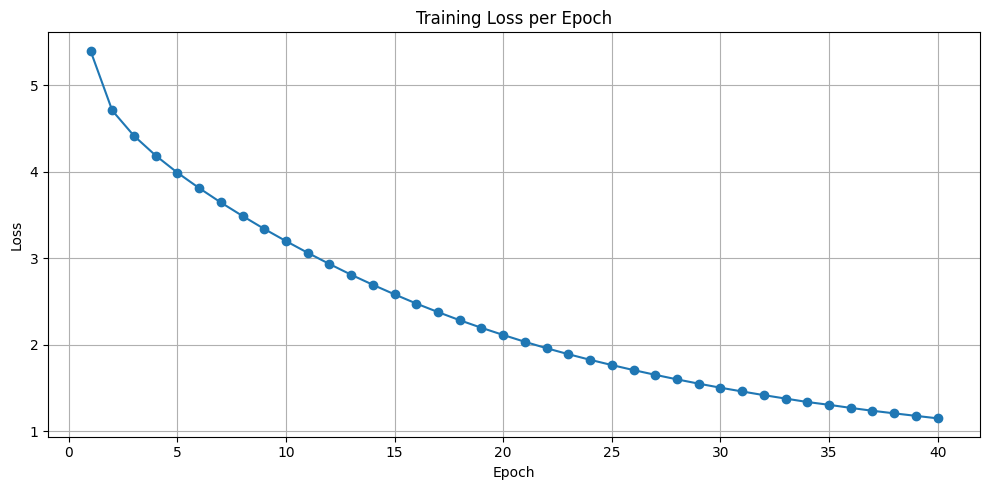

In [ ]:
import matplotlib.pyplot as plt

# Store losses
train_losses = []

# Training function with loss tracking, shuffling, and gradient clipping
def train_model(model, X, Y, epochs=40, batch_size=64):
    model.train()
    for epoch in range(epochs):
        # Shuffle data each epoch
        indices = torch.randperm(len(X))
        X = X[indices]
        Y = Y[indices]

        epoch_loss = 0
        for i in range(0, len(X), batch_size):
            x_batch = X[i:i+batch_size].to(device)
            y_batch = Y[i:i+batch_size].to(device)

            tgt_input = y_batch[:, :-1]
            tgt_output = y_batch[:, 1:]

            logits = model(x_batch, tgt_input)
            loss = criterion(logits.view(-1, vocab_size), tgt_output.reshape(-1))

            optimizer.zero_grad()
            loss.backward()

            # Gradient clipping (very helpful in LSTM + Attention models)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / (len(X) // batch_size)
        train_losses.append(avg_loss)
        print(f"Epoch {epoch+1} Avg Loss: {avg_loss:.4f}")

# Call training
train_model(model, X_train, Y_train, epochs=40, batch_size=64)

# Plot loss curve
def plot_loss_curve(losses):
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(losses)+1), losses, marker='o', linestyle='-')
    plt.title('Training Loss per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Call plotting function
plot_loss_curve(train_losses)


In [ ]:
# Define path to save in your MyDrive
save_path = "/content/gdrive/MyDrive/chatbot_dailydialog_seq2seq_with_attention.pth"

# Save model weights
torch.save(model.state_dict(), save_path)
print(f"Model saved to {save_path}")

Model saved to /content/gdrive/MyDrive/chatbot_dailydialog_seq2seq_with_attention.pth


In [ ]:
import torch

# Recreate your model architecture
model = Seq2Seq(encoder, decoder).to(device)  # ✅ FIXED


# Define path where model was saved
load_path = "/content/gdrive/MyDrive/chatbot_dailydialog_seq2seq_with_attention.pth"

# Load the saved weights
model.load_state_dict(torch.load(load_path, map_location=device))

# Set the model to evaluation mode
model.eval()

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(21080, 128, padding_idx=0)
    (lstm): LSTM(128, 256, batch_first=True)
  )
  (decoder): DecoderWithAttention(
    (embedding): Embedding(21080, 128, padding_idx=0)
    (lstm): LSTM(384, 256, batch_first=True)
    (fc): Linear(in_features=256, out_features=21080, bias=True)
    (attention): Attention(
      (attn): Linear(in_features=512, out_features=256, bias=True)
    )
  )
)

In [ ]:
# Function to tokenize user input into a tensor
def encode_input_text(text, word2idx, max_len=20):
    tokens = text.lower().split()
    indices = [bos_idx] + [word2idx.get(token, unk_idx) for token in tokens][:max_len-2] + [eos_idx]
    padded = indices + [pad_idx] * (max_len - len(indices))
    return torch.tensor(padded, dtype=torch.long)

# Greedy prediction with attention
def predict(model, question_tensor, max_len=20):
    model.eval()
    with torch.no_grad():
        question_tensor = question_tensor.unsqueeze(0).to(device)  # [1, seq_len]
        encoder_outputs, (hidden, cell) = model.encoder(question_tensor, return_outputs=True)

        input = torch.tensor([[bos_idx]]).to(device)  # [1, 1]
        output_tokens = []

        for _ in range(max_len):
            embedded = model.decoder.embedding(input)  # [1, 1, embed_size]

            # Attention context
            attn_weights = model.decoder.attention(hidden.permute(1, 0, 2), encoder_outputs)  # [1, seq_len]
            attn_weights = attn_weights.unsqueeze(1)  # [1, 1, seq_len]
            context = torch.bmm(attn_weights, encoder_outputs)  # [1, 1, hidden_size]

            lstm_input = torch.cat((embedded, context), dim=2)  # [1, 1, embed + hidden]
            output, (hidden, cell) = model.decoder.lstm(lstm_input, (hidden, cell))  # [1, 1, hidden]
            prediction = model.decoder.fc(output.squeeze(1))  # [1, vocab_size]

            pred_token = prediction.argmax(1).item()
            if pred_token == eos_idx:
                break

            output_tokens.append(idx2word.get(pred_token, "<unk>"))
            input = torch.tensor([[pred_token]]).to(device)

        return " ".join(output_tokens) if output_tokens else "<no answer>"

# Chat loop
print("\n Chatbot with Attention is ready! Type a message (or 'no question'/Enter to exit):\n")

while True:
    user_input = input("You: ").strip()
    if user_input.lower() == "no question" or user_input == "":
        print("Chatbot: Goodbye!")
        break

      # Soft prompt injection to steer tone
    #user_input = user_input + " Please respond kindly."

    # Encode the question and generate a prediction
    q_tensor = encode_input_text(user_input, word2idx).to(device)
    response = predict(model, q_tensor)

    print(f"Chatbot: {response}\n")



 Chatbot with Attention is ready! Type a message (or 'no question'/Enter to exit):

You: the kitchen stinks
Chatbot: would you please clean it later

You: would you like to grab a coffee with me tonight ?
Chatbot: id love itworking but im not sure why that id like to do with the work of the

You: would you like to eat dinner with me tonight ?
Chatbot: oh i see well have some nice talk with you

You: Are you going to the annual party tonight ?
Chatbot: yes i am

You: Can you send me a cab to pick me up ?\
Chatbot: sure

You: no question
Chatbot: Goodbye!


In [ ]:
# Function to tokenize user input into a tensor
def encode_input_text(text, word2idx, max_len=20):
    tokens = text.lower().split()
    indices = [bos_idx] + [word2idx.get(token, unk_idx) for token in tokens][:max_len-2] + [eos_idx]
    padded = indices + [pad_idx] * (max_len - len(indices))
    return torch.tensor(padded, dtype=torch.long)

# Greedy prediction with attention
def predict(model, question_tensor, max_len=20):
    model.eval()
    with torch.no_grad():
        question_tensor = question_tensor.unsqueeze(0).to(device)  # [1, seq_len]
        encoder_outputs, (hidden, cell) = model.encoder(question_tensor, return_outputs=True)

        input = torch.tensor([[bos_idx]]).to(device)  # [1, 1]
        output_tokens = []

        for _ in range(max_len):
            embedded = model.decoder.embedding(input)  # [1, 1, embed_size]

            # Attention context
            attn_weights = model.decoder.attention(hidden.permute(1, 0, 2), encoder_outputs)  # [1, seq_len]
            attn_weights = attn_weights.unsqueeze(1)  # [1, 1, seq_len]
            context = torch.bmm(attn_weights, encoder_outputs)  # [1, 1, hidden_size]

            lstm_input = torch.cat((embedded, context), dim=2)  # [1, 1, embed + hidden]
            output, (hidden, cell) = model.decoder.lstm(lstm_input, (hidden, cell))  # [1, 1, hidden]
            prediction = model.decoder.fc(output.squeeze(1))  # [1, vocab_size]

            pred_token = prediction.argmax(1).item()
            if pred_token == eos_idx:
                break

            output_tokens.append(idx2word.get(pred_token, "<unk>"))
            input = torch.tensor([[pred_token]]).to(device)

        return " ".join(output_tokens) if output_tokens else "<no answer>"

# Chat loop
print("\n Chatbot with Attention is ready! Type a message (or 'no question'/Enter to exit):\n")

while True:
    user_input = input("You: ").strip()
    if user_input.lower() == "no question" or user_input == "":
        print("Chatbot: Goodbye!")
        break

      # Soft prompt injection to steer tone
    #user_input = user_input + " Please respond kindly."

    # Encode the question and generate a prediction
    q_tensor = encode_input_text(user_input, word2idx).to(device)
    response = predict(model, q_tensor)

    print(f"Chatbot: {response}\n")



 Chatbot with Attention is ready! Type a message (or 'no question'/Enter to exit):

You: What kind of food do you like ?
Chatbot: i like spaghetti do you know

You: Do you think you can fix my computer ?
Chatbot: of course not you i am sorry about that what about you what happened

You: Does this bus go there ?
Chatbot: i think so

You: Can you leave a message for her to call her office ?
Chatbot: yes id love to

You: Is that expensive ?
Chatbot: yes i can tell you about it i dont think so

You: Shall we buy this ?
Chatbot: yes its the latest model in this district

You: How was your test ?
Chatbot: it was very successful

You: What kind of music do you like ?
Chatbot: i like chinese english especially chinese writing chinese and western music and i always dream about getting some

You: Where is the nearest bank ?
Chatbot: its near the basement of course its for you

You: Could you tell me where I can find the Clothing Department ?
Chatbot: you had a car park in the bank there as you 

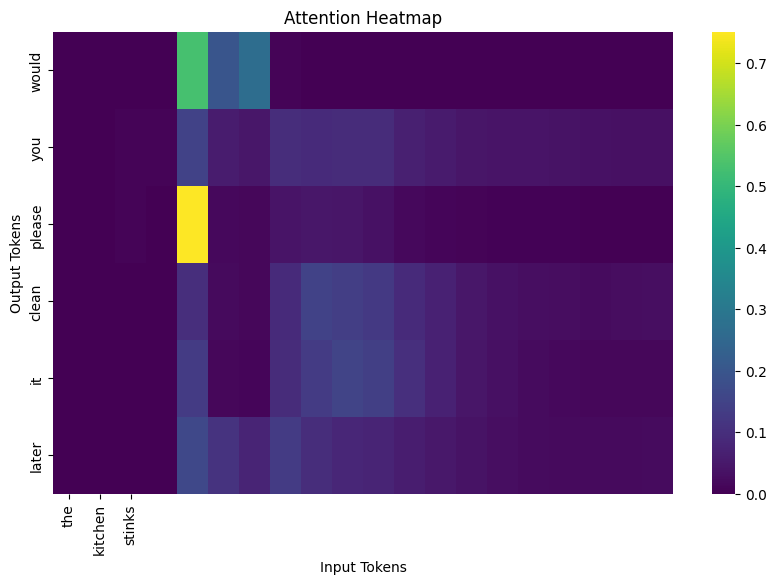

In [ ]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt

# Function: Predict and return both output and attention weights
def predict_with_attention(model, question_tensor, max_len=20):
    model.eval()
    with torch.no_grad():
        question_tensor = question_tensor.unsqueeze(0).to(device)  # [1, seq_len]
        encoder_outputs, (hidden, cell) = model.encoder(question_tensor, return_outputs=True)

        input_token = torch.tensor([[bos_idx]]).to(device)
        output_tokens = []
        all_attn_weights = []

        for _ in range(max_len):
            embedded = model.decoder.embedding(input_token)
            attn_weights = model.decoder.attention(hidden.permute(1, 0, 2), encoder_outputs)  # [1, seq_len]
            all_attn_weights.append(attn_weights.squeeze(0).cpu().numpy())  # Store for heatmap

            context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs)  # [1, 1, hidden_size]
            lstm_input = torch.cat((embedded, context), dim=2)
            output, (hidden, cell) = model.decoder.lstm(lstm_input, (hidden, cell))
            prediction = model.decoder.fc(output.squeeze(1))

            pred_token = prediction.argmax(1).item()
            if pred_token == eos_idx:
                break

            output_tokens.append(idx2word.get(pred_token, "<unk>"))
            input_token = torch.tensor([[pred_token]]).to(device)

        return output_tokens, all_attn_weights

# Function: Plot the attention weights as a heatmap
def plot_attention_heatmap(attn_weights, input_tokens, output_tokens):
    import numpy as np
    attention_matrix = np.array(attn_weights[:len(output_tokens)])

    plt.figure(figsize=(10, 6))
    sns.heatmap(attention_matrix,
                xticklabels=input_tokens,
                yticklabels=output_tokens,
                cmap='viridis',
                annot=False,
                cbar=True)
    plt.xlabel("Input Tokens")
    plt.ylabel("Output Tokens")
    plt.title("Attention Heatmap")
    plt.show()

# === Usage ===
# Example input
input_text = "the kitchen stinks"
input_tokens = input_text.lower().split()

# Encode input
q_tensor = encode_input_text(input_text, word2idx).to(device)

# Predict with attention
predicted_words, attention_weights = predict_with_attention(model, q_tensor)

# Plot
plot_attention_heatmap(attention_weights, input_tokens, predicted_words)


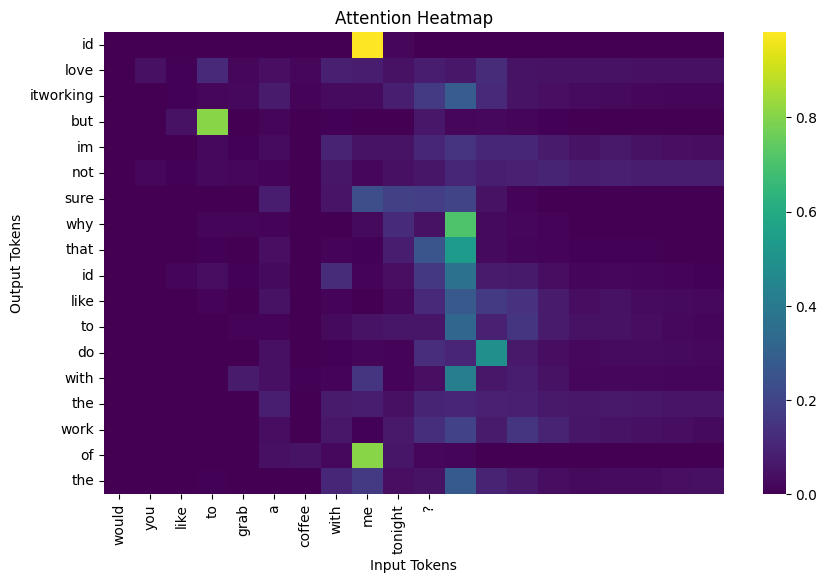

In [ ]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt

# Function: Predict and return both output and attention weights
def predict_with_attention(model, question_tensor, max_len=20):
    model.eval()
    with torch.no_grad():
        question_tensor = question_tensor.unsqueeze(0).to(device)  # [1, seq_len]
        encoder_outputs, (hidden, cell) = model.encoder(question_tensor, return_outputs=True)

        input_token = torch.tensor([[bos_idx]]).to(device)
        output_tokens = []
        all_attn_weights = []

        for _ in range(max_len):
            embedded = model.decoder.embedding(input_token)
            attn_weights = model.decoder.attention(hidden.permute(1, 0, 2), encoder_outputs)  # [1, seq_len]
            all_attn_weights.append(attn_weights.squeeze(0).cpu().numpy())  # Store for heatmap

            context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs)  # [1, 1, hidden_size]
            lstm_input = torch.cat((embedded, context), dim=2)
            output, (hidden, cell) = model.decoder.lstm(lstm_input, (hidden, cell))
            prediction = model.decoder.fc(output.squeeze(1))

            pred_token = prediction.argmax(1).item()
            if pred_token == eos_idx:
                break

            output_tokens.append(idx2word.get(pred_token, "<unk>"))
            input_token = torch.tensor([[pred_token]]).to(device)

        return output_tokens, all_attn_weights

# Function: Plot the attention weights as a heatmap
def plot_attention_heatmap(attn_weights, input_tokens, output_tokens):
    import numpy as np
    attention_matrix = np.array(attn_weights[:len(output_tokens)])

    plt.figure(figsize=(10, 6))
    sns.heatmap(attention_matrix,
                xticklabels=input_tokens,
                yticklabels=output_tokens,
                cmap='viridis',
                annot=False,
                cbar=True)
    plt.xlabel("Input Tokens")
    plt.ylabel("Output Tokens")
    plt.title("Attention Heatmap")
    plt.show()

# === Usage ===
# Example input
input_text = "would you like to grab a coffee with me tonight ?"
input_tokens = input_text.lower().split()

# Encode input
q_tensor = encode_input_text(input_text, word2idx).to(device)

# Predict with attention
predicted_words, attention_weights = predict_with_attention(model, q_tensor)

# Plot
plot_attention_heatmap(attention_weights, input_tokens, predicted_words)


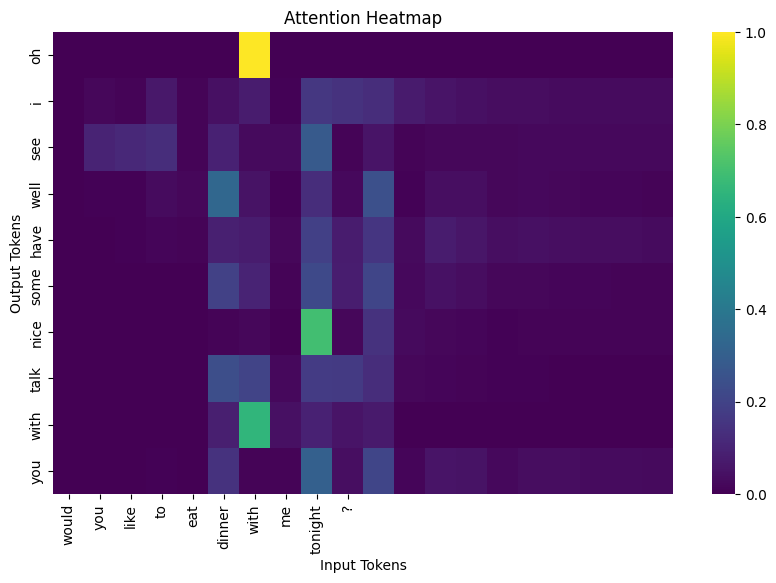

In [ ]:

# Function to tokenize user input into a tensor
def encode_input_text(text, word2idx, max_len=20):
    tokens = text.lower().split()
    indices = [bos_idx] + [word2idx.get(token, unk_idx) for token in tokens][:max_len-2] + [eos_idx]
    padded = indices + [pad_idx] * (max_len - len(indices))
    return torch.tensor(padded, dtype=torch.long)


import torch
import seaborn as sns
import matplotlib.pyplot as plt

# Function: Predict and return both output and attention weights
def predict_with_attention(model, question_tensor, max_len=20):
    model.eval()
    with torch.no_grad():
        question_tensor = question_tensor.unsqueeze(0).to(device)  # [1, seq_len]
        encoder_outputs, (hidden, cell) = model.encoder(question_tensor, return_outputs=True)

        input_token = torch.tensor([[bos_idx]]).to(device)
        output_tokens = []
        all_attn_weights = []

        for _ in range(max_len):
            embedded = model.decoder.embedding(input_token)
            attn_weights = model.decoder.attention(hidden.permute(1, 0, 2), encoder_outputs)  # [1, seq_len]
            all_attn_weights.append(attn_weights.squeeze(0).cpu().numpy())  # Store for heatmap

            context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs)  # [1, 1, hidden_size]
            lstm_input = torch.cat((embedded, context), dim=2)
            output, (hidden, cell) = model.decoder.lstm(lstm_input, (hidden, cell))
            prediction = model.decoder.fc(output.squeeze(1))

            pred_token = prediction.argmax(1).item()
            if pred_token == eos_idx:
                break

            output_tokens.append(idx2word.get(pred_token, "<unk>"))
            input_token = torch.tensor([[pred_token]]).to(device)

        return output_tokens, all_attn_weights

# Function: Plot the attention weights as a heatmap
def plot_attention_heatmap(attn_weights, input_tokens, output_tokens):
    import numpy as np
    attention_matrix = np.array(attn_weights[:len(output_tokens)])

    plt.figure(figsize=(10, 6))
    sns.heatmap(attention_matrix,
                xticklabels=input_tokens,
                yticklabels=output_tokens,
                cmap='viridis',
                annot=False,
                cbar=True)
    plt.xlabel("Input Tokens")
    plt.ylabel("Output Tokens")
    plt.title("Attention Heatmap")
    plt.show()

# === Usage ===
# Example input
input_text = "would you like to eat dinner with me tonight ?"
input_tokens = input_text.lower().split()

# Encode input
q_tensor = encode_input_text(input_text, word2idx).to(device)

# Predict with attention
predicted_words, attention_weights = predict_with_attention(model, q_tensor)

# Plot
plot_attention_heatmap(attention_weights, input_tokens, predicted_words)


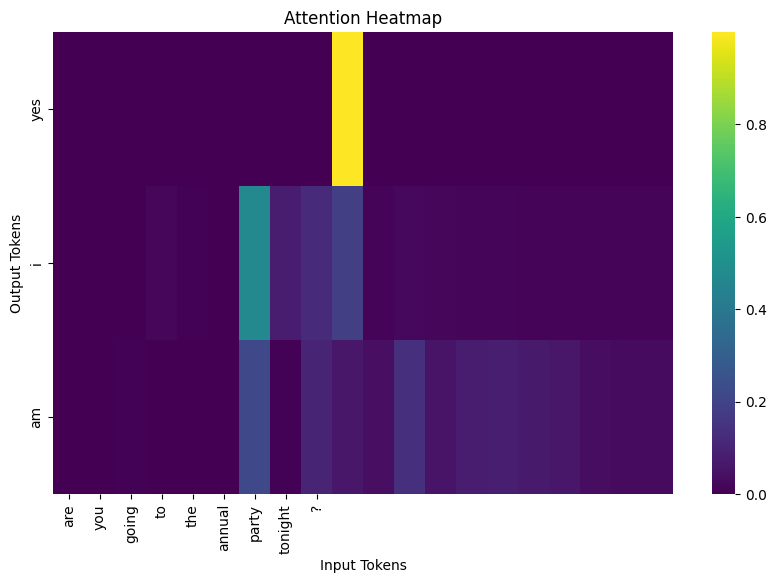

In [ ]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt

# Function: Predict and return both output and attention weights
def predict_with_attention(model, question_tensor, max_len=20):
    model.eval()
    with torch.no_grad():
        question_tensor = question_tensor.unsqueeze(0).to(device)  # [1, seq_len]
        encoder_outputs, (hidden, cell) = model.encoder(question_tensor, return_outputs=True)

        input_token = torch.tensor([[bos_idx]]).to(device)
        output_tokens = []
        all_attn_weights = []

        for _ in range(max_len):
            embedded = model.decoder.embedding(input_token)
            attn_weights = model.decoder.attention(hidden.permute(1, 0, 2), encoder_outputs)  # [1, seq_len]
            all_attn_weights.append(attn_weights.squeeze(0).cpu().numpy())  # Store for heatmap

            context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs)  # [1, 1, hidden_size]
            lstm_input = torch.cat((embedded, context), dim=2)
            output, (hidden, cell) = model.decoder.lstm(lstm_input, (hidden, cell))
            prediction = model.decoder.fc(output.squeeze(1))

            pred_token = prediction.argmax(1).item()
            if pred_token == eos_idx:
                break

            output_tokens.append(idx2word.get(pred_token, "<unk>"))
            input_token = torch.tensor([[pred_token]]).to(device)

        return output_tokens, all_attn_weights

# Function: Plot the attention weights as a heatmap
def plot_attention_heatmap(attn_weights, input_tokens, output_tokens):
    import numpy as np
    attention_matrix = np.array(attn_weights[:len(output_tokens)])

    plt.figure(figsize=(10, 6))
    sns.heatmap(attention_matrix,
                xticklabels=input_tokens,
                yticklabels=output_tokens,
                cmap='viridis',
                annot=False,
                cbar=True)
    plt.xlabel("Input Tokens")
    plt.ylabel("Output Tokens")
    plt.title("Attention Heatmap")
    plt.show()

# === Usage ===
# Example input
input_text = "Are you going to the annual party tonight ?"
input_tokens = input_text.lower().split()

# Encode input
q_tensor = encode_input_text(input_text, word2idx).to(device)

# Predict with attention
predicted_words, attention_weights = predict_with_attention(model, q_tensor)

# Plot
plot_attention_heatmap(attention_weights, input_tokens, predicted_words)


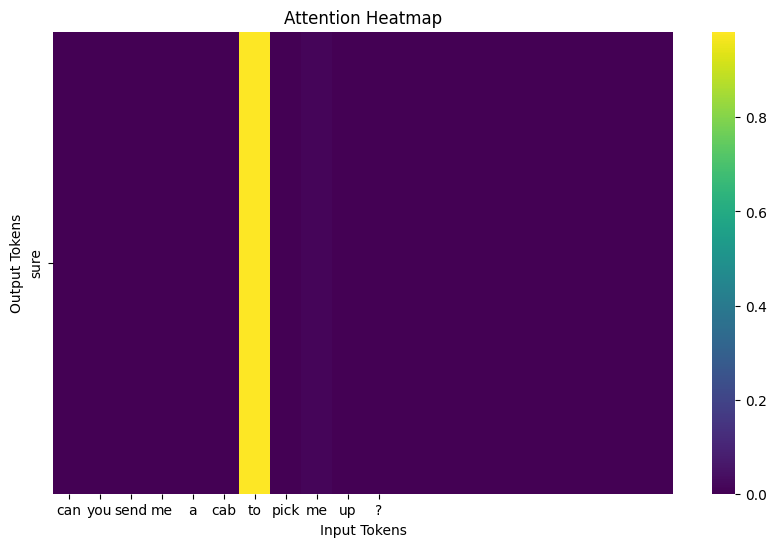

In [ ]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt

# Function: Predict and return both output and attention weights
def predict_with_attention(model, question_tensor, max_len=20):
    model.eval()
    with torch.no_grad():
        question_tensor = question_tensor.unsqueeze(0).to(device)  # [1, seq_len]
        encoder_outputs, (hidden, cell) = model.encoder(question_tensor, return_outputs=True)

        input_token = torch.tensor([[bos_idx]]).to(device)
        output_tokens = []
        all_attn_weights = []

        for _ in range(max_len):
            embedded = model.decoder.embedding(input_token)
            attn_weights = model.decoder.attention(hidden.permute(1, 0, 2), encoder_outputs)  # [1, seq_len]
            all_attn_weights.append(attn_weights.squeeze(0).cpu().numpy())  # Store for heatmap

            context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs)  # [1, 1, hidden_size]
            lstm_input = torch.cat((embedded, context), dim=2)
            output, (hidden, cell) = model.decoder.lstm(lstm_input, (hidden, cell))
            prediction = model.decoder.fc(output.squeeze(1))

            pred_token = prediction.argmax(1).item()
            if pred_token == eos_idx:
                break

            output_tokens.append(idx2word.get(pred_token, "<unk>"))
            input_token = torch.tensor([[pred_token]]).to(device)

        return output_tokens, all_attn_weights

# Function: Plot the attention weights as a heatmap
def plot_attention_heatmap(attn_weights, input_tokens, output_tokens):
    import numpy as np
    attention_matrix = np.array(attn_weights[:len(output_tokens)])

    plt.figure(figsize=(10, 6))
    sns.heatmap(attention_matrix,
                xticklabels=input_tokens,
                yticklabels=output_tokens,
                cmap='viridis',
                annot=False,
                cbar=True)
    plt.xlabel("Input Tokens")
    plt.ylabel("Output Tokens")
    plt.title("Attention Heatmap")
    plt.show()

# === Usage ===
# Example input
input_text = "Can you send me a cab to pick me up ?"
input_tokens = input_text.lower().split()

# Encode input
q_tensor = encode_input_text(input_text, word2idx).to(device)

# Predict with attention
predicted_words, attention_weights = predict_with_attention(model, q_tensor)

# Plot
plot_attention_heatmap(attention_weights, input_tokens, predicted_words)


In [ ]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

smoothie = SmoothingFunction().method4

def compute_bleu(predictions, references):
    scores = []
    for pred, ref in zip(predictions, references):
        ref_tokens = ref.lower().split()
        pred_tokens = pred.lower().split()
        score = sentence_bleu([ref_tokens], pred_tokens, smoothing_function=smoothie)
        scores.append(score)
    return sum(scores) / len(scores)

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

# Step 1: Create a DataLoader for batching
batch_size = 64  # You can adjust this based on your GPU capacity
test_dataset = TensorDataset(X_test, Y_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

generated_responses = []
ground_truth_answers = []

# Step 2: Run batched inference
with torch.no_grad():
    for src_batch, trg_batch in test_loader:
        src_batch = src_batch.to(device)
        trg_batch = trg_batch.to(device)

        # Pass source and target input (except <eos>) to the model
        output = model(src_batch, trg_batch[:, :-1])  # shape: [batch_size, seq_len, vocab_size]
        output_indices = output.argmax(dim=-1)        # shape: [batch_size, seq_len]

        # Step 3: Convert predictions and targets to token strings
        for pred_seq, target_seq in zip(output_indices, trg_batch):
            pred_tokens = [idx2word.get(idx.item(), "") for idx in pred_seq if idx.item() not in {pad_idx, eos_idx}]
            trg_tokens = [idx2word.get(idx.item(), "") for idx in target_seq if idx.item() not in {pad_idx, bos_idx}]

            generated_responses.append(" ".join(pred_tokens))
            ground_truth_answers.append(" ".join(trg_tokens))



In [ ]:
bleu_score = compute_bleu(generated_responses, ground_truth_answers)
print(f"BLEU Score (with Attention): {bleu_score:.4f}")

BLEU Score (with Attention): 0.0870


In [ ]:
!pip install rouge-score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=d63a431aea09f1fa20e58a130c2ab6cc62089e87ddd79d15b77f2ec9d3c41d02
  Stored in directory: /root/.cache/pip/wheels/1e/19/43/8a442dc83660ca25e163e1bd1f89919284ab0d0c1475475148
Successfully built rouge-score


In [ ]:
from rouge_score import rouge_scorer

def compute_rouge(predictions, references):
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    rouge1, rouge2, rougel = [], [], []

    for pred, ref in zip(predictions, references):
        scores = scorer.score(ref, pred)
        rouge1.append(scores['rouge1'].fmeasure)
        rouge2.append(scores['rouge2'].fmeasure)
        rougel.append(scores['rougeL'].fmeasure)

    avg_r1 = sum(rouge1) / len(rouge1)
    avg_r2 = sum(rouge2) / len(rouge2)
    avg_rl = sum(rougel) / len(rougel)

    return avg_r1, avg_r2, avg_rl

# Example usage (use your generated_responses and ground_truth_answers lists):
rouge_1, rouge_2, rouge_L = compute_rouge(generated_responses, ground_truth_answers)

print(f"ROUGE-1 (F1): {rouge_1:.4f}")
print(f"ROUGE-2 (F1): {rouge_2:.4f}")
print(f"ROUGE-L (F1): {rouge_L:.4f}")


ROUGE-1 (F1): 0.2569
ROUGE-2 (F1): 0.1052
ROUGE-L (F1): 0.2429
